In [37]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import csv

# Step 2: Load dataset safely
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

# Load with error handling
df = pd.read_csv("imdb_review.csv", quoting=csv.QUOTE_NONE, encoding='utf-8', on_bad_lines='skip')

# Step 3: Preprocess reviews
def preprocess(text):
    text = str(text).lower()                          # lowercase
    text = re.sub('[^a-z]', ' ', text)                # remove punctuation
    tokens = text.split()                             # tokenize
    tokens = [ps.stem(word) for word in tokens if word not in stop_words]  # remove stopwords + stem
    return " ".join(tokens)

df['clean_review'] = df['review'].apply(preprocess)

# Convert sentiment to numerical labels (0 for negative, 1 for positive)
df['sentiment_numeric'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Drop rows where sentiment_numeric could not be determined (i.e., was NaN)
df_cleaned = df.dropna(subset=['sentiment_numeric'])

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned['clean_review'], df_cleaned['sentiment_numeric'], test_size=0.2, random_state=42, stratify=df_cleaned['sentiment_numeric']
)

# Step 5: Vectorization
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step 6: Train Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

# Step 7: Predict
y_pred = nb.predict(X_test_vec)

# Step 8: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, nb.predict_proba(X_test_vec)[:,1]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.4838709677419355
Precision: 0.5
Recall: 0.3125
F1 Score: 0.38461538461538464
Confusion Matrix:
 [[10  5]
 [11  5]]
ROC-AUC: 0.61875


Classification Report:

              precision    recall  f1-score   support

    negative       0.48      0.67      0.56        15
    positive       0.50      0.31      0.38        16

    accuracy                           0.48        31
   macro avg       0.49      0.49      0.47        31
weighted avg       0.49      0.48      0.47        31



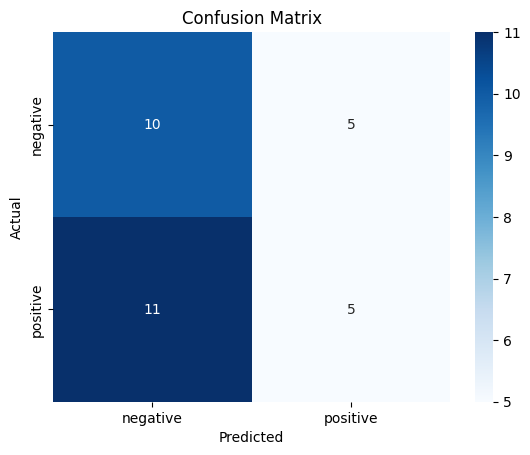

ROC-AUC Score: 0.61875


In [39]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy, Precision, Recall, F1
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['negative','positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative','positive'], yticklabels=['negative','positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC Score
roc_score = roc_auc_score(y_test, nb.predict_proba(X_test_vec)[:,1])
print("ROC-AUC Score:", roc_score)

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Top 5 Selected Features: Index(['radius_mean', 'texture_se', 'radius_worst', 'compactness_worst',
       'concavity_worst'],
      dtype='object')
Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412
ROC-AUC: 0.9983622666229938

Comparison:
Accuracy (All Features): 0.956140350877193
Accuracy (Selected Features): 0.9736842105263158


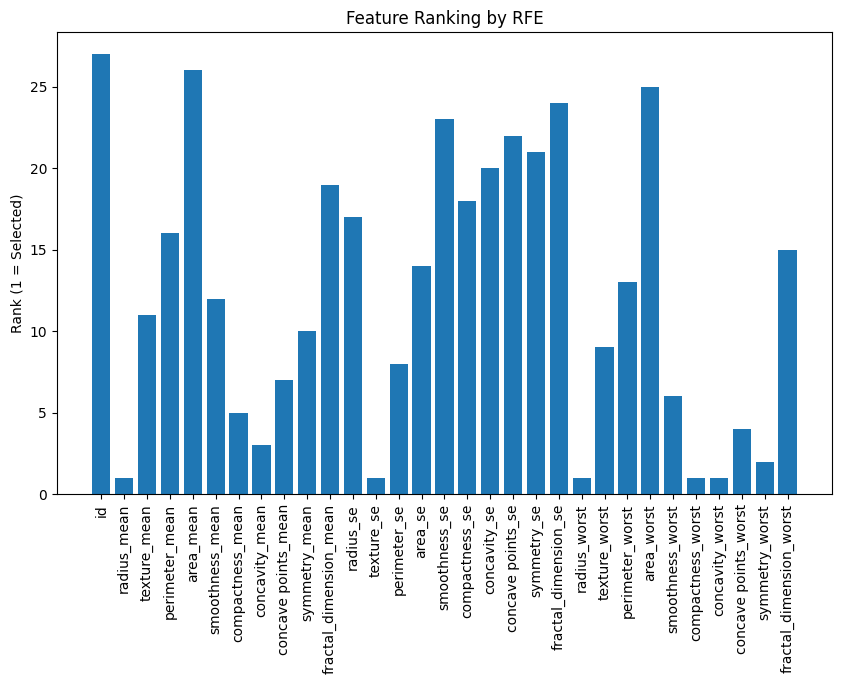

In [45]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

# Step 2: Load dataset
# Adjust filename/path to your dataset
data = pd.read_csv("breast_cancer.csv")

# Step 3: Basic EDA
print(data.describe())
print("Missing values:\n", data.isnull().sum())

# Drop the 'Unnamed: 32' column as it contains only NaN values
if 'Unnamed: 32' in data.columns:
    data = data.drop(columns=['Unnamed: 32'])

# Separate features and target
X = data.drop('diagnosis', axis=1)   # assuming 'diagnosis' column is the target
y = data['diagnosis']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Apply RFE with Logistic Regression
logreg = LogisticRegression(max_iter=1000)
rfe = RFE(logreg, n_features_to_select=5)
rfe.fit(X_train, y_train)

# Selected features
selected_features = X_train.columns[rfe.support_]
print("Top 5 Selected Features:", selected_features)

# Step 6: Train model with selected features
logreg.fit(X_train[selected_features], y_train)
y_pred_rfe = logreg.predict(X_test[selected_features])

# Step 7: Evaluate model with selected features
print("Accuracy:", accuracy_score(y_test, y_pred_rfe))
print("Precision:", precision_score(y_test, y_pred_rfe, pos_label='M'))
print("Recall:", recall_score(y_test, y_pred_rfe, pos_label='M'))
print("F1 Score:", f1_score(y_test, y_pred_rfe, pos_label='M'))
print("ROC-AUC:", roc_auc_score(y_test.map({'M':1, 'B':0}), logreg.predict_proba(X_test[selected_features])[:,1]))

# Step 8: Compare with all features
logreg.fit(X_train, y_train)
y_pred_all = logreg.predict(X_test)

print("\nComparison:")
print("Accuracy (All Features):", accuracy_score(y_test, y_pred_all))
print("Accuracy (Selected Features):", accuracy_score(y_test, y_pred_rfe))

# Step 9: Visualize feature ranking
ranking = rfe.ranking_
plt.figure(figsize=(10,6))
plt.bar(X_train.columns, ranking)
plt.xticks(rotation=90)
plt.title("Feature Ranking by RFE")
plt.ylabel("Rank (1 = Selected)")
plt.show()

In [48]:
# Function to run RFE with different feature counts
def run_rfe(n_features):
    logreg = LogisticRegression(max_iter=1000)
    rfe = RFE(logreg, n_features_to_select=n_features)
    rfe.fit(X_train, y_train)

    selected_features = X_train.columns[rfe.support_]
    print(f"\nTop {n_features} Selected Features:", list(selected_features))

    # Train with selected features
    logreg.fit(X_train[selected_features], y_train)
    y_pred = logreg.predict(X_test[selected_features])

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='M')
    rec = recall_score(y_test, y_pred, pos_label='M')
    f1 = f1_score(y_test, y_pred, pos_label='M')
    roc = roc_auc_score(y_test.map({'M':1, 'B':0}), logreg.predict_proba(X_test[selected_features])[:,1])

    print(f"Performance with Top {n_features} Features:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}")
    return acc, prec, rec, f1, roc

# Run experiments
results = {}
for n in [3, 5, 7]:
    results[n] = run_rfe(n)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Top 3 Selected Features: ['texture_se', 'compactness_worst', 'concavity_worst']
Performance with Top 3 Features:
Accuracy: 0.8070, Precision: 0.8889, Recall: 0.5581, F1: 0.6857, ROC-AUC: 0.9374


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Top 5 Selected Features: ['radius_mean', 'texture_se', 'radius_worst', 'compactness_worst', 'concavity_worst']
Performance with Top 5 Features:
Accuracy: 0.9737, Precision: 0.9762, Recall: 0.9535, F1: 0.9647, ROC-AUC: 0.9984


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Top 7 Selected Features: ['radius_mean', 'concavity_mean', 'texture_se', 'radius_worst', 'compactness_worst', 'concavity_worst', 'symmetry_worst']
Performance with Top 7 Features:
Accuracy: 0.9737, Precision: 0.9762, Recall: 0.9535, F1: 0.9647, ROC-AUC: 0.9984
